# Bonus Content

Hi! In this bonus notebook we are going to run our agent with a pretty gamified sprites simulaion as shown in the project banner, we are going to keep it simple. 

#### So, first we load the necessary dependencies. 

In [1]:
from TwoRoomEnvironment import TwoRoomMDP
from QLearningAgent import QLearningAgent
from BoardGenerator import BoardGenerator
from IPython.display import Video

#### Board, Hyperparams and Constants

Second we initialize the board hyperparams and constants we used before

In [2]:
AGENT_PATH= "Q_Learning_Agent"
board_4x9 = [
    [' ',      ' ',         ' ',          ' ',  '#',                ' ', ' ', ' ', 'END'  ],
    ['S',      ' ',  'KEY_blue',          ' ',  '#',                ' ', ' ', ' ',   ' '  ],
    [' ',      ' ',         ' ',          ' ',  '#',                ' ', ' ', ' ',   ' '  ],
    [' ',      ' ',         ' ',   'BALL_red',  'DOOR_LOCKED_blue', ' ', ' ', ' ',   ' '  ]
]
dimensions_4x9 = (4,9)

ALPHA_NEW = 0.9
GAMMA_NEW = 0.001
EPSILON_NEW = 0.01
EPSILON_DECAY_NEW = 0.9
EPSILON_MIN_NEW = 1e-15 #0.0000000001 
EPISODES_NEW = 20000

#### Environment, Agent and Recorder

Then initialize the components: environment, agent, and recorder using the previous board a hyperparams and constants

In [3]:
eval_gen = BoardGenerator(board_4x9)
eval_board = eval_gen.generate()
eval_env = TwoRoomMDP(board= eval_board, dimensions=dimensions_4x9)

evaluation_agent = QLearningAgent(eval_env, #<--- our evaluation  environment 
                           gamma=GAMMA_NEW, 
                           alpha=ALPHA_NEW, 
                           epsilon=EPSILON_NEW, epsilon_decay = EPSILON_DECAY_NEW, epsilon_min = EPSILON_MIN_NEW, 
                           episodes = EPISODES_NEW)
evaluation_agent.load(AGENT_PATH)
sprites_recorder = evaluation_agent.get_sprite_recorder(path = "videos/sprites_recorder.mp4", fps = 5)


[load] Loaded Q-table (628 entries) ← Q_Learning_Agent


Show current env state inline to verify how is the environment going to look 

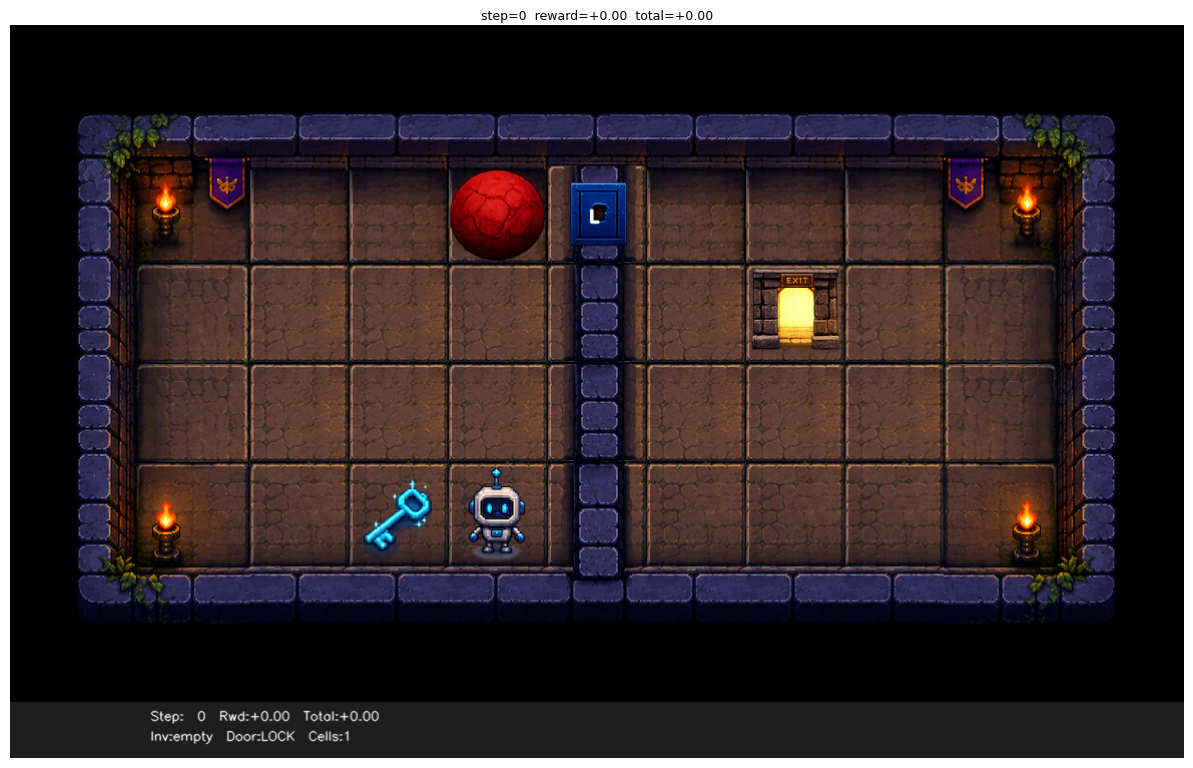

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       ...,

       [[30, 30, 30],
        [30, 30, 30],
        [30, 30, 30],
        ...,
        [30, 30, 30],
        [30, 30, 30],
        [30, 30, 30]],

       [[30, 30, 30],
        [30, 30, 30],
        [30, 30, 30],
        ...,
        [30, 30, 30],
        [30, 30, 30],
        [30, 30, 30]],

       [[30, 30, 30],
        [30, 30, 30],
        [30, 30, 30],
        ...,
        [30, 30, 30],
        [30, 30, 30],
        [30, 30, 30]]], dtype=uint8)

In [4]:
sprites_recorder.debug_frame()

#### Run
Run the simulation

In [5]:
evaluation_agent.evaluate(recorder = sprites_recorder)

100%|██████████| 100/100 [01:08<00:00,  1.47it/s]

Saved to videos/sprites_recorder.mp4


{'success_rate': 1.0,
 'mean_reward': 129.90880000000004,
 'std_reward': 0.45018502862710985,
 'mean_steps': 59.56,
 'std_steps': 22.50925143135595,
 'n_episodes': 100,
 'n_successes': 100}

Then play the video

In [6]:
Video("videos/sprites_recorder.mp4")
